1. You will be given a code cell that calculates the coefficients of a quadratic model () between two variables. All code in this cell will be correct. Then in the next code cell, a figure is generated with a scatter plot of the individual data and a line plot of the model prediction. However, the plot is obviously wrong. Make necessary modifications to generate a correct plot.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df_financial = pd.read_csv("data_raw/financial.csv")

In [ ]:
#
model = smf.ols(formula="points ~ laps + grid", data=df_results)

coeffs = model.fit().params

a = coeffs['laps']
b = coeffs['grid']
c = coeffs['Intercept']

grid_val = 3
laps_val = 55

predicted_points = a * laps_val + b * grid_val + c

print("Predicted points:", predicted_points)

##______________________________________________________________________________________________________________________
#**Important:** Whatever variable you put on the x-axis, the data better be sorted by that variable!!

# ✅ Sort by the x-variable (date)
df_sorted = df_financial.sort_values(by="date")
display(df_sorted)

# Plot date vs. S&P 500
plt.figure(figsize=(8,5))
plt.plot(df_sorted["date"], df_sorted["sp500"], marker='o', linestyle='-')

# Label axes and add title
plt.xlabel("Time")
plt.ylabel("S&P 500 Index")
plt.title("S&P 500 over Time")
plt.grid(True)
plt.show()
#______________________________________________________________________________________________________________________
# Use the Pandas datetime to convert the column to datetime format from str
# We'll add a new column to the DataFrame

df_financial["date"] = pd.to_datetime(df_financial["date_str"])
display(df_financial.head())

2. Read in a .csv file to create a DataFrame which contains weather data for Delhi, India in the year 2017. Using the ".plot()" method, generate a single line plot with (time vs. temperature) and (time vs. wind speed). The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.

In [ ]:
# 1️⃣ Read the CSV file into a DataFrame
# Read CSV file
df_weather = pd.read_csv("delhi_weather_2017.csv")

# Convert date column to datetime
df_weather["date"] = pd.to_datetime(df_weather["date"])

# ✅ Use the Pandas .plot() method
df_weather[["date", "temperature", "wind_speed"]].set_index("date").plot(figsize=(10,6))

# Add labels and title
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Delhi Weather 2017: Temperature and Wind Speed Over Time")
plt.grid(True)
plt.show()

3. Read in a .csv file to create a DataFrame which contains conversion rates for Euros to U.S. dollars and British Pounds to U.S. dollars over time. Compute non-dimensional percentage growth values for each and plot together on a single plot. (You can use matplotlib.pyplot or the .plot() method connected to a DataFrame).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Read in the CSV file
df_currency = pd.read_csv("conversion_rates.csv")

# 2️⃣ Convert 'date' column to datetime format
df_currency["date"] = pd.to_datetime(df_currency["date"])

# 3️⃣ Compute daily (or sequential) percentage growth for both conversion rates
df_currency["growth_euro_usd"] = (
    df_currency["euro_to_usd"].diff() / df_currency["euro_to_usd"].shift(1)
) * 100

df_currency["growth_gbp_usd"] = (
    df_currency["gbp_to_usd"].diff() / df_currency["gbp_to_usd"].shift(1)
) * 100

# 4️⃣ Display a few relevant columns to confirm calculations
display(df_currency[["date", "euro_to_usd", "growth_euro_usd", "gbp_to_usd", "growth_gbp_usd"]].head())

# 5️⃣ Plot both growth series on one figure
plt.plot("date", "growth_euro_usd", data=df_currency, alpha=0.85)
plt.plot("date", "growth_gbp_usd", data=df_currency, alpha=0.75)

# 6️⃣ Label axes and add title + legend
plt.xlabel("Time")
plt.ylabel("Daily Percentage Change (%)")
plt.title("Percentage Change in Euro→USD and GBP→USD Exchange Rates Over Time")
plt.legend(["Euro→USD", "GBP→USD"])
plt.grid(True)
plt.show()

4. Continuing with the DataFrame of conversion rates, create a new column of Boolean type, which checks whether the conversion rate for one of the currencies was greater than a given value.

In [ ]:
# Assuming df_currency already exists and contains:
# "date", "euro_to_usd", "gbp_to_usd"

# 1️⃣ Define a threshold value (for example, 1.15 USD per Euro)
threshold_value = 1.15

# 2️⃣ Create a Boolean column checking if euro_to_usd > threshold_value
df_currency["euro_above_threshold"] = df_currency["euro_to_usd"] > threshold_value

# 3️⃣ Display results and data types
display(df_currency.head())
display(df_currency.dtypes)

5. Continuing Problem 4, make a line plot of the conversion rate for this currency and highlight regions where the conversion rate is larger than a given value, using the function "plt.fill_between"

In [2]:
# Define shorthand variables for clarity
x_vals = df_currency["date"]
y_vals = df_currency["euro_to_usd"]
condition = df_currency["euro_above_threshold"]

# 1️⃣ Plot the exchange rate line
plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, color="blue", label="Euro→USD Exchange Rate")

# 2️⃣ Highlight periods when the rate was above the threshold
plt.fill_between(
    x=x_vals,
    y1=y_vals.min(),
    y2=y_vals.max(),
    where=condition,
    alpha=0.2,
    color="red",
    label="Above Threshold"
)

NameError: name 'df_currency' is not defined

6. A code cell creates a DataFrame with the following columns. All columns are numerical:

time: A column containing evenly spaced values between 
 and 
. Denote them by 
sin: A column containing the sine function evaluated at those points. I.e. 
cos: A column containing the cosine function evaluated at those points. I.e. 
Using the ".diff()" method, create a new column called "d_sin_dt" with the following formula: 
.

From calculus, this should be close to 
, so plot (time vs. cos) and (time vs. d_sin_dt) together on a single figure to it.

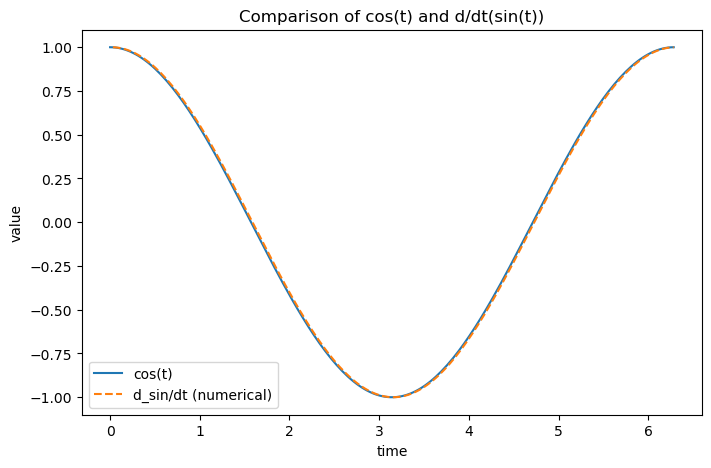

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create evenly spaced time values between 0 and 2π
time = np.linspace(0, 2*np.pi, 200)

# Create a DataFrame with sin and cos values
df = pd.DataFrame({
    "time": time,
    "sin": np.sin(time),
    "cos": np.cos(time)
})

# Compute the numerical derivative using .diff()
df["d_sin_dt"] = df["sin"].diff() / df["time"].diff()

# Plot (time vs cos) and (time vs d_sin_dt) together
plt.figure(figsize=(8,5))
plt.plot(df["time"], df["cos"], label="cos(t)")
plt.plot(df["time"], df["d_sin_dt"], label="d_sin/dt (numerical)", linestyle='--')
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.title("Comparison of cos(t) and d/dt(sin(t))")
plt.show()